### Step 2：直接转录法(Direct Transcription) 轨迹优化（无约束）

目标：从下垂静止态 $[x, \theta, \dot{x}, \dot{\theta}] = [0, 0, 0, 0]$ 到直立平衡态 $[0, \pi, 0, 0]$，寻找一条**开环**最优轨迹。

直接转录法实现：
- 把连续时间轨迹离散成 $N$ 个采样点
- 用系统动力学在相邻采样点间施加等式约束
- 通过代价函数（比如输入能量 + 时间）让轨迹更好
- 求解后得到一条**开环**轨迹，Step 3 再加入硬约束 $|x|\le L, |u|\le u_{\max}$

In [1]:
# 配置环境
import numpy as np
import matplotlib.pyplot as plt
from pydrake.all import (
    DirectCollocation,
    DiagramBuilder,
    MeshcatVisualizer,
    MultibodyPlant,
    MultibodyPositionToGeometryPose,
    Parser,
    PiecewisePolynomial,
    SceneGraph,
    Simulator,
    SnoptSolver,
    Solve,
    StartMeshcat,
    TrajectorySource,
    )
from underactuated import ConfigureParser


In [2]:
#直接转录法求解函数
def cartpole_step2_direct_transcription(
    num_time_samples=21,
    dt_min=0.05,
    dt_max=0.2,
    u_weight=1.0,
    time_weight=1.0,
    ):
    # 构建植物模型
    plant = MultibodyPlant(time_step=0.0)
    parser = Parser(plant)
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()
    context = plant.CreateDefaultContext()

    # 直接转录设置
    dircol = DirectCollocation(
        plant,
        context,
        num_time_samples=num_time_samples,
        minimum_time_step=dt_min,
        maximum_time_step=dt_max,
        input_port_index=plant.get_actuation_input_port().get_index(),
    )

    # 初末态约束（从下垂到直立）
    x0 = np.array([0.0, 0.0, 0.0, 0.0])
    xf = np.array([0.0, np.pi, 0.0, 0.0])
    prog = dircol.prog()
    prog.AddBoundingBoxConstraint(x0, x0, dircol.initial_state())
    prog.AddBoundingBoxConstraint(xf, xf, dircol.final_state())

    # 代价函数（输入能量 + 时间）
    u = dircol.input()
    dircol.AddRunningCost(u_weight * u[0] ** 2)
    dircol.AddFinalCost(time_weight * dircol.time())

    # 初始猜测
    state_guess = PiecewisePolynomial.FirstOrderHold(
        [0.0, 1.0], np.vstack((x0, xf)).T
    )
    input_guess = PiecewisePolynomial.FirstOrderHold(
        [0.0, 1.0], np.zeros((1, 2))
    )
    dircol.SetInitialTrajectory(input_guess, state_guess)

    # 求解
    solver = SnoptSolver()
    if solver.available():
        result = solver.Solve(prog)
    else:
        result = Solve(prog)

    if not result.is_success():
        print(" Step 2 求解失败：请尝试调整 num_time_samples / dt_min / dt_max 或初始猜测")
        return None

    # 重建轨迹并可视化
    xtraj = dircol.ReconstructStateTrajectory(result)
    utraj = dircol.ReconstructInputTrajectory(result)
    ts = np.linspace(xtraj.start_time(), xtraj.end_time(), 201)
    x_samples = xtraj.vector_values(ts)
    u_samples = utraj.vector_values(ts)

    fig, axes = plt.subplots(3, 2, figsize=(10, 8))
    axes = axes.flatten()
    labels = ["x (m)", "theta (rad)", "x_dot (m/s)", "theta_dot (rad/s)"]
    for i in range(4):
        axes[i].plot(ts, x_samples[i, :], "b-")
        axes[i].set_title(labels[i])
        axes[i].grid(True)
    axes[4].plot(ts, u_samples[0, :], "r-")
    axes[4].set_title("u (N)")
    axes[4].grid(True)
    axes[5].axis("off")
    plt.suptitle("Step 2: Direct Transcription (Open-loop)")
    plt.tight_layout()
    plt.show()

    print(f"求解成功")
    return xtraj, utraj


对于上面的函数，我们可以微微改变num_time_samples，它的值会影响轨迹求解的精度，越大越精细，但越难求解；


下面运行函数可以得到我们的解，并且生成四个变量随时间变化的示意图。

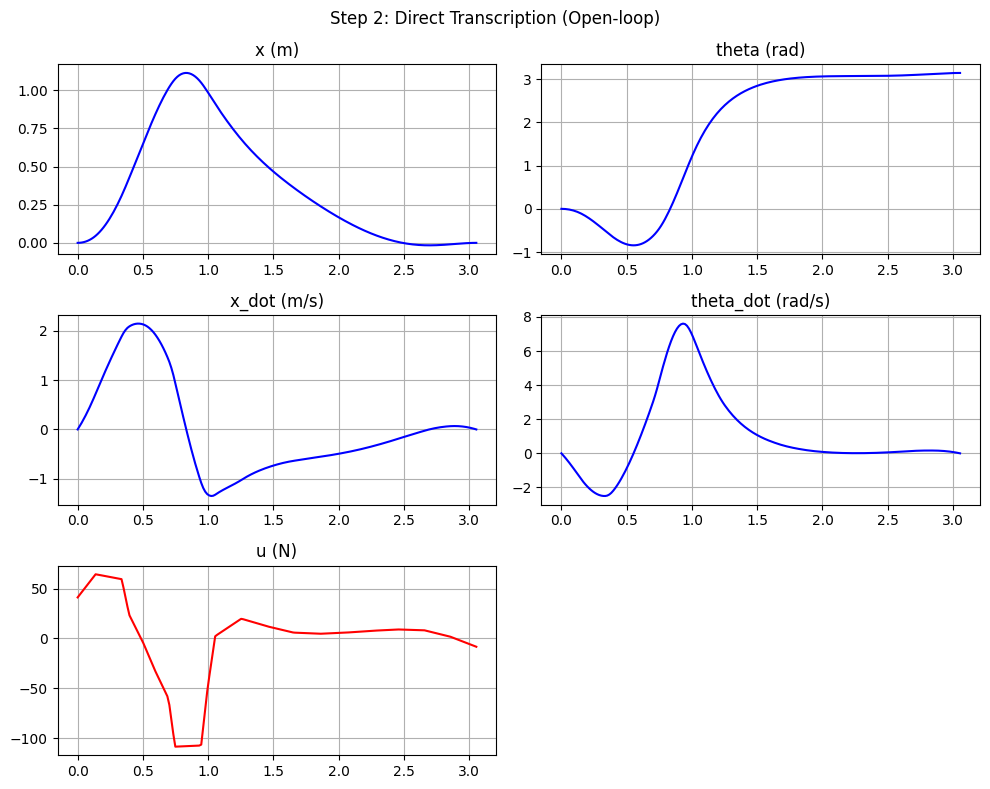

求解成功


In [3]:
# 运行函数
xtraj, utraj = cartpole_step2_direct_transcription()

运行下面单元可以看相位图。

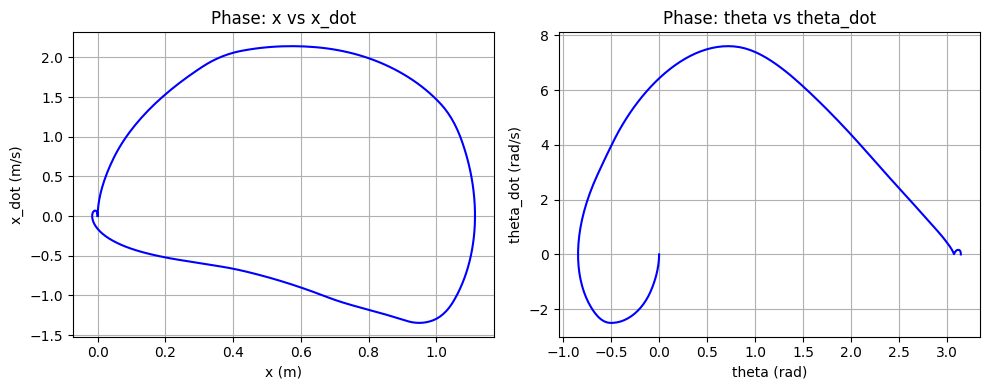

In [4]:
# 相位图
def plot_phase_portraits(xtraj, num_samples=400):
    if xtraj is None:
        print("没有相位图可画，请先成功求解")
        return
    ts = np.linspace(xtraj.start_time(), xtraj.end_time(), num_samples)
    x_samples = xtraj.vector_values(ts)
    x = x_samples[0, :]
    theta = x_samples[1, :]
    xdot = x_samples[2, :]
    thetadot = x_samples[3, :]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(x, xdot, "b-")
    axes[0].set_xlabel("x (m)")
    axes[0].set_ylabel("x_dot (m/s)")
    axes[0].set_title("Phase: x vs x_dot")
    axes[0].grid(True)

    axes[1].plot(theta, thetadot, "b-")
    axes[1].set_xlabel("theta (rad)")
    axes[1].set_ylabel("theta_dot (rad/s)")
    axes[1].set_title("Phase: theta vs theta_dot")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# 运行相位图
plot_phase_portraits(xtraj)

下面可以将刚刚的优化过程可视化。

In [5]:
# 轨迹可视化（Meshcat 回放）
def visualize_cartpole_trajectory(xtraj):
    if xtraj is None:
        print("没有可视化的轨迹，请先成功求解")
        return

    meshcat = StartMeshcat()
    builder = DiagramBuilder()
    plant = MultibodyPlant(time_step=0.0)
    scene_graph = builder.AddSystem(SceneGraph())
    plant.RegisterAsSourceForSceneGraph(scene_graph)
    parser = Parser(plant, scene_graph)
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()

    source = builder.AddSystem(TrajectorySource(xtraj))
    pos_to_pose = builder.AddSystem(
        MultibodyPositionToGeometryPose(plant, input_multibody_state=True)
    )
    builder.Connect(source.get_output_port(0), pos_to_pose.get_input_port())
    builder.Connect(
        pos_to_pose.get_output_port(),
        scene_graph.get_source_pose_port(plant.get_source_id()),
    )
    meshcat.Set2dRenderMode(xmin=-2.5, xmax=2.5, ymin=-1.0, ymax=2.5)
    visualizer = MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
    diagram = builder.Build()
    simulator = Simulator(diagram)

    visualizer.StartRecording(False)
    simulator.AdvanceTo(xtraj.end_time())
    visualizer.PublishRecording()

# 回放
visualize_cartpole_trajectory(xtraj)

INFO:drake:Meshcat listening for connections at http://localhost:7002
